Roll No: 24BAD022
Name: Divyadharshini S
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset Path: /kaggle/input/intel-image-classification
Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.

Dataset Information
----------------------------------------
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of Classes: 6
Training Batches: 351
Validation Batches: 88
Testing Batches: 94


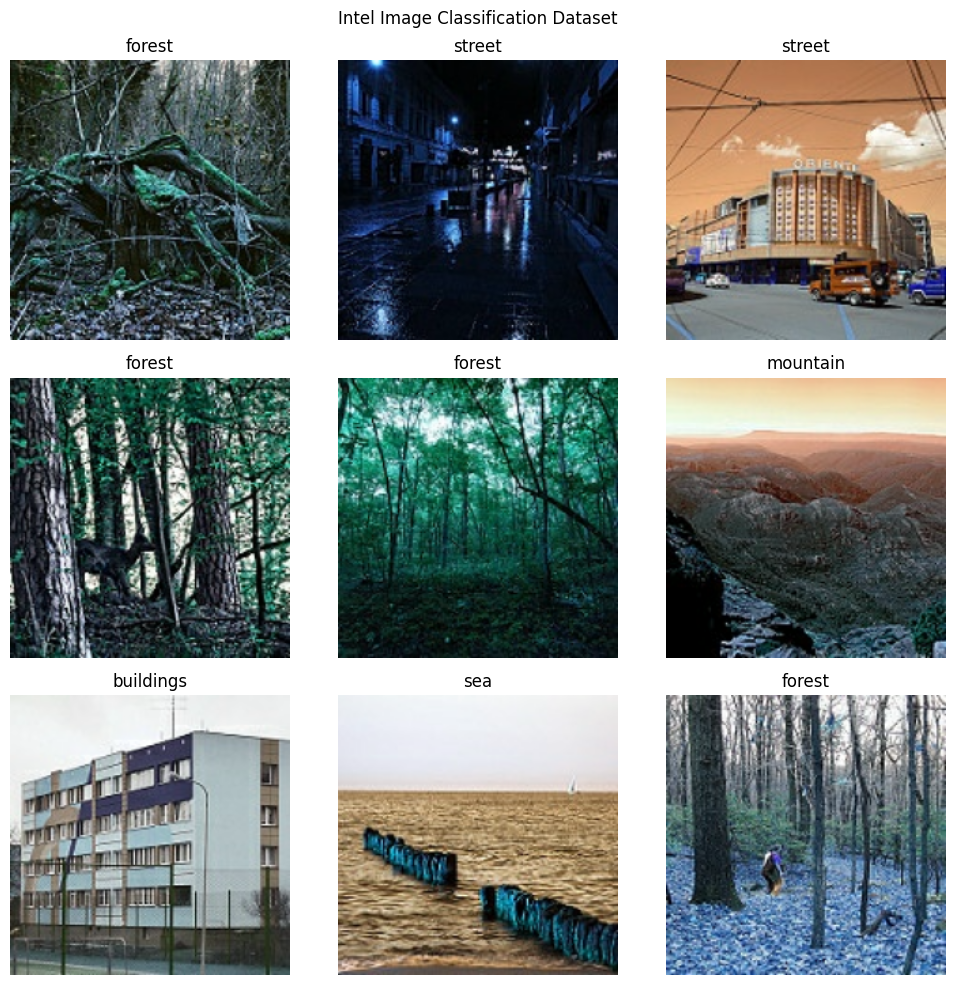

In [ ]:
print("Roll No: 24BAD022")
print("Name: Divyadharshini S")

!pip install -q kagglehub

import kagglehub
import tensorflow as tf
import matplotlib.pyplot as plt
import os

dataset_path = kagglehub.dataset_download("puneet6060/intel-image-classification")

print("Dataset Path:", dataset_path)

train_dir = os.path.join(dataset_path, "seg_train", "seg_train")
test_dir = os.path.join(dataset_path, "seg_test", "seg_test")

IMG_SIZE = (224,224)
BATCH_SIZE = 32
SEED = 42

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

from tensorflow.keras.applications.resnet50 import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)
val_dataset = val_dataset.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)
test_dataset = test_dataset.map(lambda x,y:(preprocess_input(x),y)).prefetch(AUTOTUNE)

print("\nDataset Information")
print("-"*40)
print("Classes:", class_names)
print("Number of Classes:", len(class_names))
print("Training Batches:", tf.data.experimental.cardinality(train_dataset).numpy())
print("Validation Batches:", tf.data.experimental.cardinality(val_dataset).numpy())
print("Testing Batches:", tf.data.experimental.cardinality(test_dataset).numpy())

plt.figure(figsize=(10,10))
for images,labels in train_dataset.take(1):
    images = (images + [103.939,116.779,123.68])/255.0
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(tf.clip_by_value(images[i],0,1))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.suptitle("Intel Image Classification Dataset")
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False
inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)
model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [ ]:
history1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=8
)

base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10
)

test_loss, test_acc = model.evaluate(test_dataset)

print(f"Testing Accuracy: {test_acc*100:.2f}%")
print(f"Testing Loss: {test_loss:.4f}")

train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]

plt.figure(figsize=(8,5))

plt.plot(train_acc,label="Training Accuracy")
plt.plot(val_acc,label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

train_loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Training Loss")
plt.plot(val_loss,label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

print("\nFinal Performance Summary")

print("-"*60)

print(f"{'Metric':<25}{'Value'}")

print("-"*60)

print(f"{'Training Accuracy':<25}{train_acc[-1]:.4f}")
print(f"{'Validation Accuracy':<25}{val_acc[-1]:.4f}")
print(f"{'Training Loss':<25}{train_loss[-1]:.4f}")
print(f"{'Validation Loss':<25}{val_loss[-1]:.4f}")
print(f"{'Testing Accuracy':<25}{test_acc:.4f}")
print(f"{'Testing Loss':<25}{test_loss:.4f}")

In [ ]:
import os

print(os.listdir(test_dir))
print(os.listdir(os.path.join(test_dir, "sea"))[:10])

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Hugging Face Vision Transformer Loaded Successfully!
Sample Image: 20513.jpg


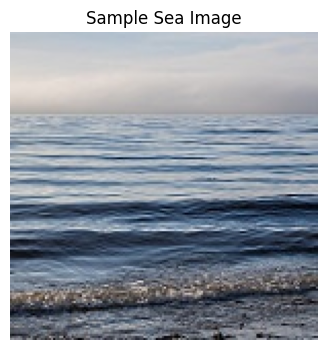


Hugging Face Prediction:
seashore, coast, seacoast, sea-coast : 0.3901
lakeside, lakeshore : 0.0737
sandbar, sand bar : 0.0462
breakwater, groin, groyne, mole, bulwark, seawall, jetty : 0.0300
Lakeland terrier : 0.0161

Comparison of Predictions


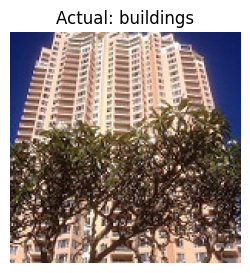

Actual Class : buildings
Predicted    : palace
Confidence   : 0.3290
--------------------------------------------------


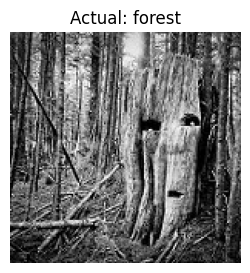

Actual Class : forest
Predicted    : chain saw, chainsaw
Confidence   : 0.1875
--------------------------------------------------


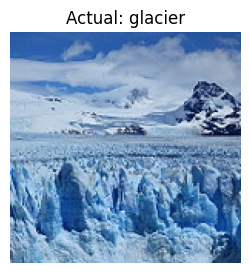

Actual Class : glacier
Predicted    : alp
Confidence   : 0.1252
--------------------------------------------------


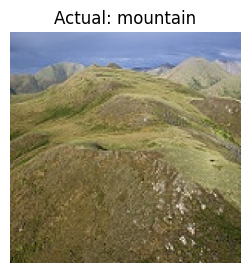

Actual Class : mountain
Predicted    : valley, vale
Confidence   : 0.4927
--------------------------------------------------


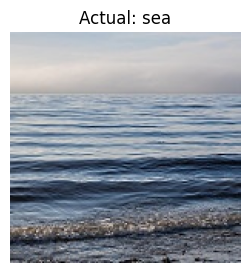

Actual Class : sea
Predicted    : seashore, coast, seacoast, sea-coast
Confidence   : 0.3901
--------------------------------------------------


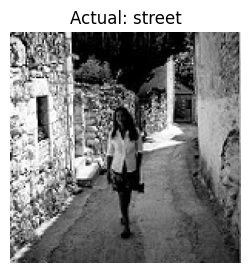

Actual Class : street
Predicted    : monastery
Confidence   : 0.6190
--------------------------------------------------

Model Saved Successfully!
Model Path: /content/TransferLearning_24BAD022.keras
README Created Successfully!
README Path: /content/README.md


In [16]:
!pip install -q transformers

from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
import glob
import os

classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face Vision Transformer Loaded Successfully!")

sample_image = glob.glob(os.path.join(test_dir, "sea", "*.jpg"))[0]
print("Sample Image:", os.path.basename(sample_image))

image = Image.open(sample_image)
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Sample Sea Image")
plt.axis("off")
plt.show()

prediction = classifier(image)

print("\nHugging Face Prediction:")
for p in prediction[:5]:
    print(f"{p['label']} : {p['score']:.4f}")

print("\nComparison of Predictions")
print("="*50)

classes = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

for cls in classes:

    img_path = glob.glob(os.path.join(test_dir, cls, "*.jpg"))[0]

    img = Image.open(img_path)

    plt.figure(figsize=(3,3))
    plt.imshow(img)
    plt.title(f"Actual: {cls}")
    plt.axis("off")
    plt.show()

    pred = classifier(img)[0]

    print(f"Actual Class : {cls}")
    print(f"Predicted    : {pred['label']}")
    print(f"Confidence   : {pred['score']:.4f}")
    print("-"*50)

save_dir = os.getcwd()
save_path = os.path.join(save_dir, "TransferLearning_24BAD022.keras")

model.save(save_path)

print("\nModel Saved Successfully!")
print("Model Path:", save_path)

readme = """# Transfer Learning Experiment

Student Name: Divyadharshini S
Roll Number: 24BAD022

Dataset:
Intel Image Classification (Kaggle)

Transfer Learning Model:
ResNet50

Hugging Face Model:
google/vit-base-patch16-224

Tasks Completed:
- Dataset Preparation
- Transfer Learning
- Model Training
- Hugging Face Image Classification
"""

readme_path = os.path.join(save_dir, "README.md")

with open(readme_path, "w") as f:
    f.write(readme)

print("README Created Successfully!")
print("README Path:", readme_path)
